# 🚗 Baseline Models — Used Car Price Prediction

This notebook trains **three baseline models** on the feature-engineered dataset and compares their performance using **MAE**, **RMSE**, and **R²** metrics.

| # | Model | Type |
|---|-------|------|
| 1 | **Linear Regression** | Linear |
| 2 | **Random Forest Regressor** | Ensemble (Bagging) |
| 3 | **XGBoost Regressor** | Ensemble (Boosting) |

## 1 · Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

RANDOM_STATE = 42
print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## 2 · Load Feature-Engineered Data

In [2]:
df = pd.read_csv('feature_engineered_car_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'Total null values: {df.isnull().sum().sum()}')
df.head()

Dataset shape: (37750, 83)
Total null values: 0


,body,km,imgCount,oem,model,variant,City,listed_price,discountValue,Engine Type,No of Cylinder,Valves per Cylinder,Length,Width,Height,Wheel Base,Front Tread,Rear Tread,Kerb Weight,Gross Weight,Gear Box,Seats,Turning Radius,Top Speed,Acceleration,Doors,Cargo Volume,state,exterior_color,Fuel Suppy System,Alloy Wheel Size,Max Power Delivered,Max Power At,Max Torque Delivered,Max Torque At,car_age,transmission_manual,fuel_diesel,fuel_electric,fuel_lpg,fuel_petrol,utype_individual,carType_corporate,carType_partner,Valve Configuration_dohc,Valve Configuration_idsi,Valve Configuration_ohv / pushrod,Valve Configuration_sohc,Turbo Charger_True,Super Charger_True,Drive Type_4wd,Drive Type_4x2,Drive Type_awd,Drive Type_fwd,Drive Type_rwd,Steering Type_power,Front Brake Type_carbon ceramic,Front Brake Type_disc,Front Brake Type_disc & drum,Front Brake Type_drum,Front Brake Type_ventilated disc,Rear Brake Type_carbon ceramic,Rear Brake Type_disc,Rear Brake Type_disc & drum,Rear Brake Type_drum,Rear Brake Type_ventilated disc,Tyre Type_tube,Tyre Type_tubeless,Tyre Type_tubeless radial,owner_type_first,owner_type_fourth,owner_type_second,owner_type_third,owner_type_unregistered car,KM_PER_YEAR,POWER_TO_WEIGHT,TORQUE_TO_POWER,ENGINE_PER_CYLINDER,CAR_VOLUME,LUXURY_BRAND_FLAG,PREMIUM_BRAND_FLAG,HIGH_MILEAGE_FLAG,OLD_CAR_FLAG
0,2,69162.0,15,29,223,2179,339,370000.0,0,345,3.0,4.0,3599.0,1515.0,1700.0,2400.0,1295.0,1290.0,960.0,1595.0,3,5.0,4.6,154.50,15.60,5.0,180.0,30,621,10,16.0,58.16,6200.0,77.0,3500.0,10.0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,6287.454545,0.060520,1.301555,14.540,9269.22450,0,0,1,0
1,2,45864.0,15,29,197,1926,379,365000.0,0,345,3.0,4.0,3600.0,1600.0,1560.0,2425.0,1420.0,1410.0,915.0,1595.0,3,5.0,4.7,154.50,15.05,5.0,235.0,18,277,7,16.0,58.20,6000.0,78.0,3500.0,11.0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,3822.000000,0.063537,1.317568,14.550,8985.60000,0,0,0,1
2,8,81506.0,15,15,85,2559,409,421000.0,0,316,4.0,4.0,3990.0,1680.0,1505.0,2405.0,1485.0,1493.0,950.0,1595.0,3,5.0,4.5,160.00,15.00,4.0,400.0,8,621,10,16.0,86.70,6000.0,109.0,4500.0,11.0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,6792.166667,0.091167,1.242873,17.340,10088.31600,0,1,1,1
3,2,115893.0,0,29,223,2179,409,240000.0,0,340,3.0,4.0,3595.0,1515.0,1700.0,2400.0,1295.0,1290.0,960.0,1595.0,3,5.0,4.6,168.56,13.20,4.0,350.0,8,621,10,13.0,58.20,6200.0,77.0,3500.0,13.0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,8278.071429,0.060562,1.300676,14.550,9258.92250,0,0,1,1
4,6,18900.0,6,29,204,3075,379,1175000.0,0,359,4.0,4.0,4395.0,1735.0,1690.0,2740.0,1485.0,1493.0,1250.0,1595.0,3,7.0,5.2,168.56,13.20,5.0,350.0,18,737,10,16.0,86.63,5500.0,121.5,4200.0,4.0,1,0,0,0,0,0,0,1,1,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,3780.000000,0.069249,1.386511,17.326,12886.79925,0,0,0,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
body,37750.0,5.723682,3.132113,0.00000,2.000000,8.000000,9.000,10.0000
km,37750.0,61047.878940,37245.742580,101.00000,31759.250000,56767.000000,83360.000,160761.1250
imgCount,37750.0,15.576079,8.362586,0.00000,10.000000,15.000000,21.000,74.0000
oem,37750.0,24.900927,10.786783,0.00000,17.000000,26.000000,29.000,45.0000
model,37750.0,177.554517,92.506303,0.00000,101.000000,184.000000,223.000,381.0000
...,...,...,...,...,...,...,...,...
CAR_VOLUME,37750.0,11239.728486,2090.395088,7076.61045,9883.294895,10919.377856,12388.978,18701.8428
LUXURY_BRAND_FLAG,37750.0,0.073113,0.260325,0.00000,0.000000,0.000000,0.000,1.0000
PREMIUM_BRAND_FLAG,37750.0,0.406649,0.491215,0.00000,0.000000,0.000000,1.000,1.0000
HIGH_MILEAGE_FLAG,37750.0,0.499974,0.500007,0.00000,0.000000,0.000000,1.000,1.0000


## 3 · Define Features & Target

**Target variable:** `listed_price`  
**Features:** All remaining columns after dropping the target and `discountValue` (potential data leakage).

In [4]:
TARGET = 'listed_price'

# Columns to drop — target + any leaky/irrelevant columns
drop_cols = [TARGET, 'discountValue']

X = df.drop(columns=drop_cols)
y = df[TARGET]

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'\nFeature columns ({X.shape[1]}):')
print(list(X.columns))

Features shape : (37750, 81)
Target shape   : (37750,)

Feature columns (81):
['body', 'km', 'imgCount', 'oem', 'model', 'variant', 'City', 'Engine Type', 'No of Cylinder', 'Valves per Cylinder', 'Length', 'Width', 'Height', 'Wheel Base', 'Front Tread', 'Rear Tread', 'Kerb Weight', 'Gross Weight', 'Gear Box', 'Seats', 'Turning Radius', 'Top Speed', 'Acceleration', 'Doors', 'Cargo Volume', 'state', 'exterior_color', 'Fuel Suppy System', 'Alloy Wheel Size', 'Max Power Delivered', 'Max Power At', 'Max Torque Delivered', 'Max Torque At', 'car_age', 'transmission_manual', 'fuel_diesel', 'fuel_electric', 'fuel_lpg', 'fuel_petrol', 'utype_individual', 'carType_corporate', 'carType_partner', 'Valve Configuration_dohc', 'Valve Configuration_idsi', 'Valve Configuration_ohv / pushrod', 'Valve Configuration_sohc', 'Turbo Charger_True', 'Super Charger_True', 'Drive Type_4wd', 'Drive Type_4x2', 'Drive Type_awd', 'Drive Type_fwd', 'Drive Type_rwd', 'Steering Type_power', 'Front Brake Type_carbon cera

## 4 · Train-Test Split

We use an **80-20 split** with a fixed random state for reproducibility.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Training set : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(X)*100:.1f}%)')

Training set : 30,200 samples  (80.0%)
Test set     : 7,550 samples  (20.0%)


## 5 · Feature Scaling

StandardScaler is applied for **Linear Regression** which is sensitive to feature magnitudes.  
Tree-based models (Random Forest, XGBoost) are scale-invariant, but we provide both scaled and unscaled data.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Scaled training set shape: {X_train_scaled.shape}')
print(f'Scaled test set shape    : {X_test_scaled.shape}')

Scaled training set shape: (30200, 81)
Scaled test set shape    : (7550, 81)


## 6 · Evaluation Helper Functions

In [7]:
def evaluate_model(model_name, y_true, y_pred):
    """Compute MAE, RMSE, R² and return as a dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    
    print(f'\n{"═" * 50}')
    print(f'  📊  {model_name}')
    print(f'{"═" * 50}')
    print(f'  MAE  : ₹{mae:,.2f}')
    print(f'  RMSE : ₹{rmse:,.2f}')
    print(f'  R²   : {r2:.4f}')
    print(f'{"═" * 50}')
    
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

# Store results for comparison
results = []

## 7 · Model 1 — Linear Regression

A simple linear model that serves as our **baseline floor**. Uses scaled features.

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test  = lr_model.predict(X_test_scaled)

print('--- Training Performance ---')
lr_train_results = evaluate_model('Linear Regression (Train)', y_train, y_pred_lr_train)

print('\n--- Test Performance ---')
lr_test_results = evaluate_model('Linear Regression (Test)', y_test, y_pred_lr_test)

results.append({
    'Model': 'Linear Regression',
    'Train MAE': lr_train_results['MAE'],
    'Train RMSE': lr_train_results['RMSE'],
    'Train R²': lr_train_results['R²'],
    'Test MAE': lr_test_results['MAE'],
    'Test RMSE': lr_test_results['RMSE'],
    'Test R²': lr_test_results['R²'],
})

--- Training Performance ---

══════════════════════════════════════════════════
  📊  Linear Regression (Train)
══════════════════════════════════════════════════
  MAE  : ₹116,208.46
  RMSE : ₹157,338.87
  R²   : 0.8798
══════════════════════════════════════════════════

--- Test Performance ---

══════════════════════════════════════════════════
  📊  Linear Regression (Test)
══════════════════════════════════════════════════
  MAE  : ₹118,221.01
  RMSE : ₹160,143.83
  R²   : 0.8760
══════════════════════════════════════════════════


## 8 · Model 2 — Random Forest Regressor

An ensemble of decision trees using **bagging**. Uses unscaled features (tree-based models are scale-invariant).

In [9]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test  = rf_model.predict(X_test)

print('--- Training Performance ---')
rf_train_results = evaluate_model('Random Forest (Train)', y_train, y_pred_rf_train)

print('\n--- Test Performance ---')
rf_test_results = evaluate_model('Random Forest (Test)', y_test, y_pred_rf_test)

results.append({
    'Model': 'Random Forest',
    'Train MAE': rf_train_results['MAE'],
    'Train RMSE': rf_train_results['RMSE'],
    'Train R²': rf_train_results['R²'],
    'Test MAE': rf_test_results['MAE'],
    'Test RMSE': rf_test_results['RMSE'],
    'Test R²': rf_test_results['R²'],
})

--- Training Performance ---

══════════════════════════════════════════════════
  📊  Random Forest (Train)
══════════════════════════════════════════════════
  MAE  : ₹29,301.16
  RMSE : ₹47,118.28
  R²   : 0.9892
══════════════════════════════════════════════════

--- Test Performance ---

══════════════════════════════════════════════════
  📊  Random Forest (Test)
══════════════════════════════════════════════════
  MAE  : ₹59,575.75
  RMSE : ₹92,294.26
  R²   : 0.9588
══════════════════════════════════════════════════


## 9 · Model 3 — XGBoost Regressor

A gradient-boosted tree model known for high predictive performance. Uses unscaled features.

In [10]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test  = xgb_model.predict(X_test)

print('--- Training Performance ---')
xgb_train_results = evaluate_model('XGBoost (Train)', y_train, y_pred_xgb_train)

print('\n--- Test Performance ---')
xgb_test_results = evaluate_model('XGBoost (Test)', y_test, y_pred_xgb_test)

results.append({
    'Model': 'XGBoost',
    'Train MAE': xgb_train_results['MAE'],
    'Train RMSE': xgb_train_results['RMSE'],
    'Train R²': xgb_train_results['R²'],
    'Test MAE': xgb_test_results['MAE'],
    'Test RMSE': xgb_test_results['RMSE'],
    'Test R²': xgb_test_results['R²'],
})

--- Training Performance ---

══════════════════════════════════════════════════
  📊  XGBoost (Train)
══════════════════════════════════════════════════
  MAE  : ₹27,139.35
  RMSE : ₹37,345.38
  R²   : 0.9932
══════════════════════════════════════════════════

--- Test Performance ---

══════════════════════════════════════════════════
  📊  XGBoost (Test)
══════════════════════════════════════════════════
  MAE  : ₹55,064.50
  RMSE : ₹85,433.89
  R²   : 0.9647
══════════════════════════════════════════════════


## 10 · Model Comparison

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

# Format for display
styled = results_df.style.format({
    'Train MAE': '₹{:,.0f}',
    'Train RMSE': '₹{:,.0f}',
    'Train R²': '{:.4f}',
    'Test MAE': '₹{:,.0f}',
    'Test RMSE': '₹{:,.0f}',
    'Test R²': '{:.4f}',
}).background_gradient(subset=['Test R²'], cmap='RdYlGn')

styled

,Train MAE,Train RMSE,Train R²,Test MAE,Test RMSE,Test R²
Model,,,,,,
Linear Regression,"₹116,208","₹157,339",0.8798,"₹118,221","₹160,144",0.8760
Random Forest,"₹29,301","₹47,118",0.9892,"₹59,576","₹92,294",0.9588
XGBoost,"₹27,139","₹37,345",0.9932,"₹55,064","₹85,434",0.9647


## 11 · Visual Comparison of Models

### 11.1 · Test Metrics Bar Chart

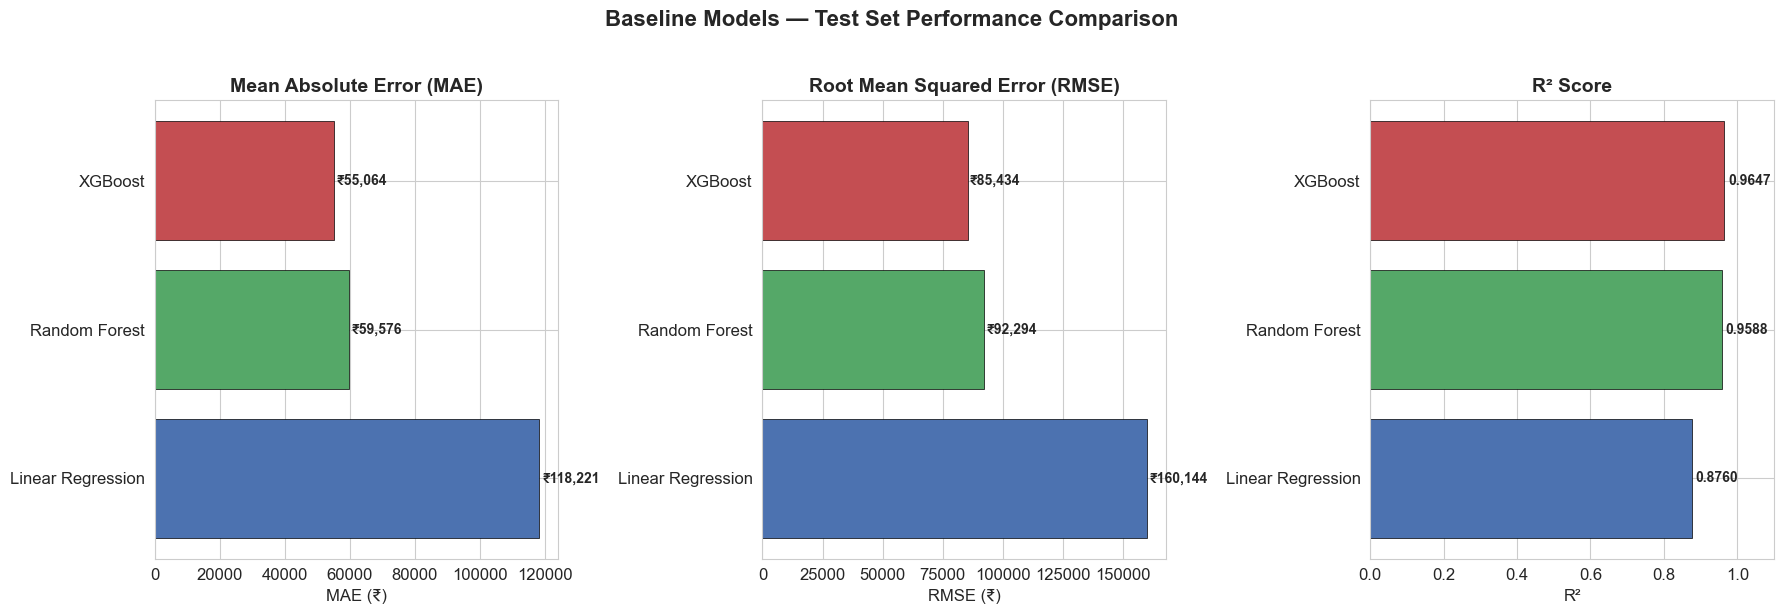

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = results_df.index.tolist()
colors = ['#4C72B0', '#55A868', '#C44E52']

# MAE
axes[0].barh(models, results_df['Test MAE'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Mean Absolute Error (MAE)', fontweight='bold')
axes[0].set_xlabel('MAE (₹)')
for i, v in enumerate(results_df['Test MAE']):
    axes[0].text(v + 1000, i, f'₹{v:,.0f}', va='center', fontweight='bold', fontsize=10)

# RMSE
axes[1].barh(models, results_df['Test RMSE'], color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Root Mean Squared Error (RMSE)', fontweight='bold')
axes[1].set_xlabel('RMSE (₹)')
for i, v in enumerate(results_df['Test RMSE']):
    axes[1].text(v + 1000, i, f'₹{v:,.0f}', va='center', fontweight='bold', fontsize=10)

# R²
bars = axes[2].barh(models, results_df['Test R²'], color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_title('R² Score', fontweight='bold')
axes[2].set_xlabel('R²')
axes[2].set_xlim(0, 1.1)
for i, v in enumerate(results_df['Test R²']):
    axes[2].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=10)

plt.suptitle('Baseline Models — Test Set Performance Comparison', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 11.2 · Train vs Test R² (Overfitting Check)

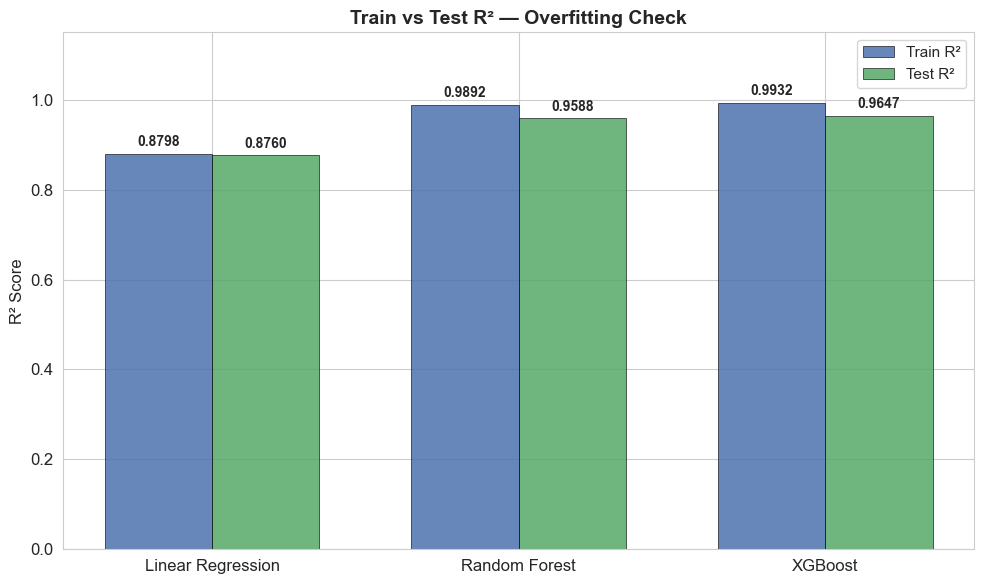

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Train R²'], width, label='Train R²', 
               color='#4C72B0', edgecolor='black', linewidth=0.5, alpha=0.85)
bars2 = ax.bar(x + width/2, results_df['Test R²'], width, label='Test R²', 
               color='#55A868', edgecolor='black', linewidth=0.5, alpha=0.85)

ax.set_ylabel('R² Score')
ax.set_title('Train vs Test R² — Overfitting Check', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)

# Add value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.4f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.4f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 12 · Residual Analysis

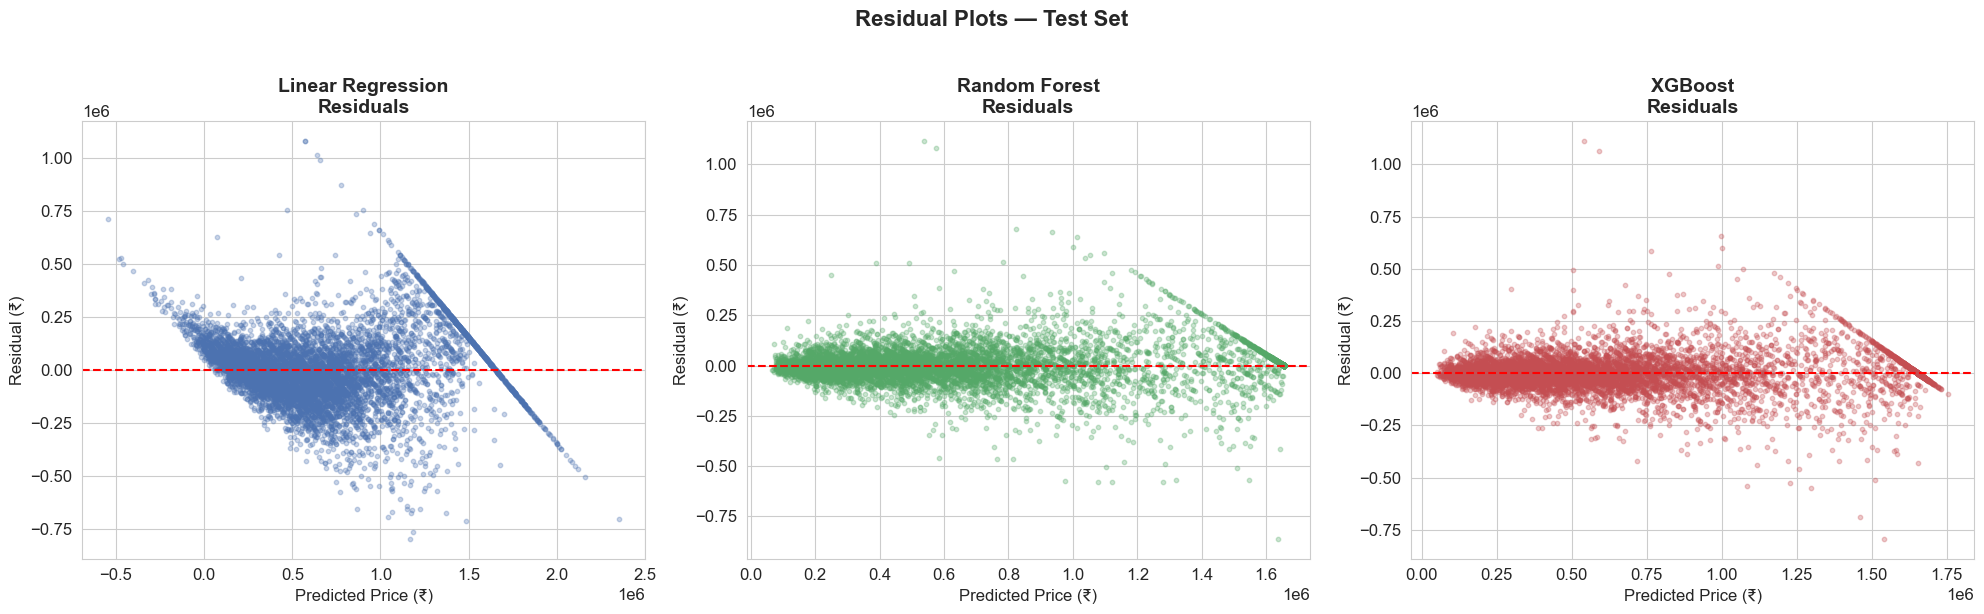

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

predictions = {
    'Linear Regression': y_pred_lr_test,
    'Random Forest': y_pred_rf_test,
    'XGBoost': y_pred_xgb_test,
}

for idx, (name, y_pred) in enumerate(predictions.items()):
    residuals = y_test - y_pred
    axes[idx].scatter(y_pred, residuals, alpha=0.3, s=10, color=colors[idx])
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'{name}\nResiduals', fontweight='bold')
    axes[idx].set_xlabel('Predicted Price (₹)')
    axes[idx].set_ylabel('Residual (₹)')

plt.suptitle('Residual Plots — Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13 · Actual vs Predicted Price

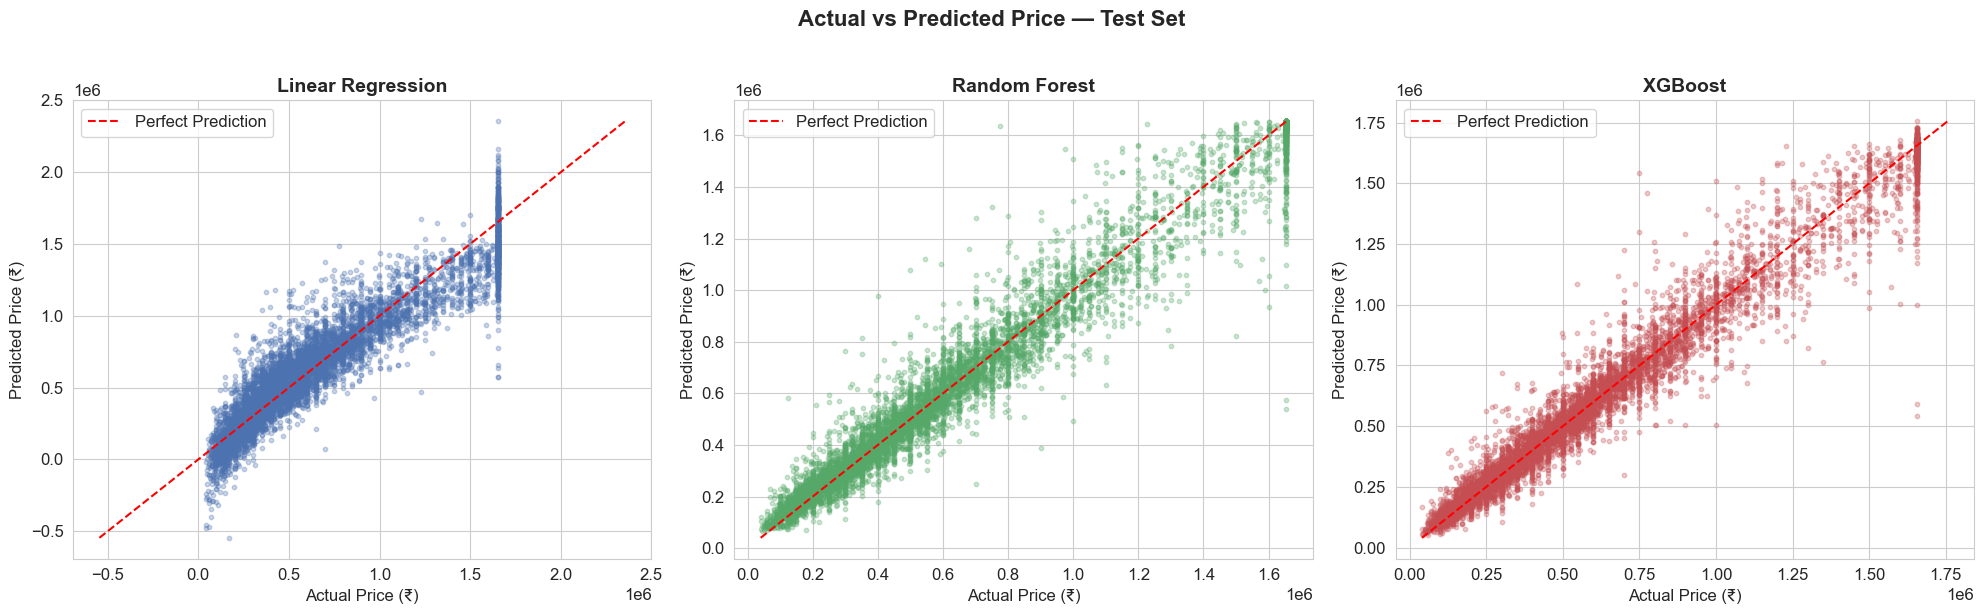

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (name, y_pred) in enumerate(predictions.items()):
    axes[idx].scatter(y_test, y_pred, alpha=0.3, s=10, color=colors[idx])
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_xlabel('Actual Price (₹)')
    axes[idx].set_ylabel('Predicted Price (₹)')
    axes[idx].legend()

plt.suptitle('Actual vs Predicted Price — Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14 · Feature Importance (Top 20)

### 14.1 · Random Forest Feature Importance

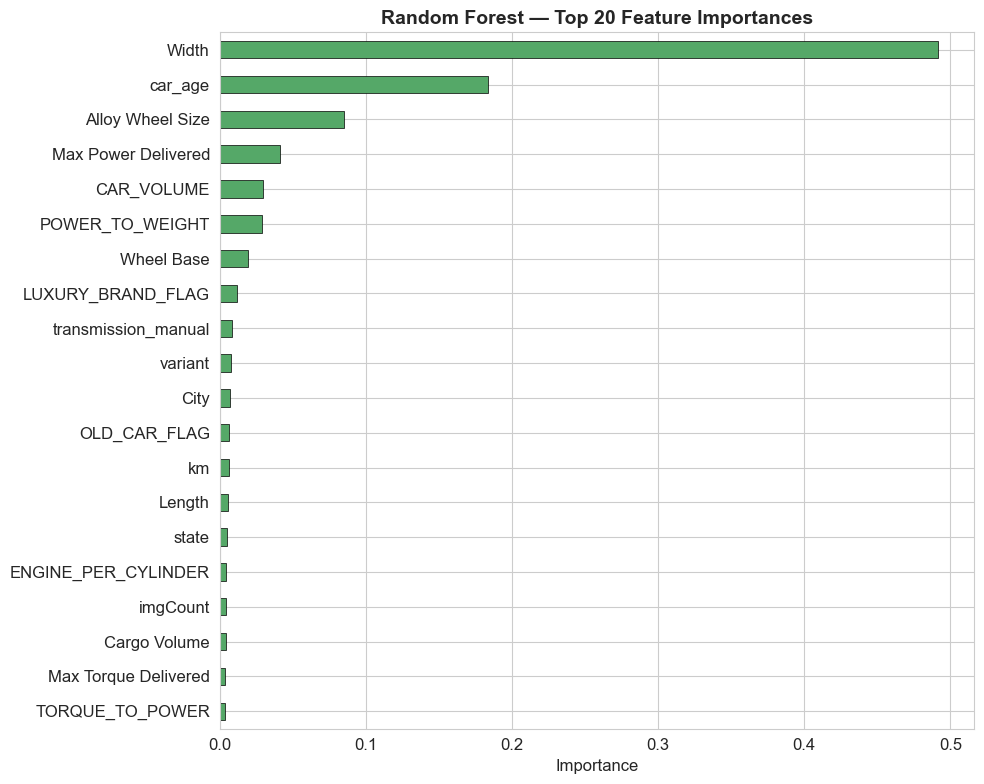

In [16]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
rf_top20 = rf_importance.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
rf_top20.sort_values().plot(kind='barh', ax=ax, color='#55A868', edgecolor='black', linewidth=0.5)
ax.set_title('Random Forest — Top 20 Feature Importances', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### 14.2 · XGBoost Feature Importance

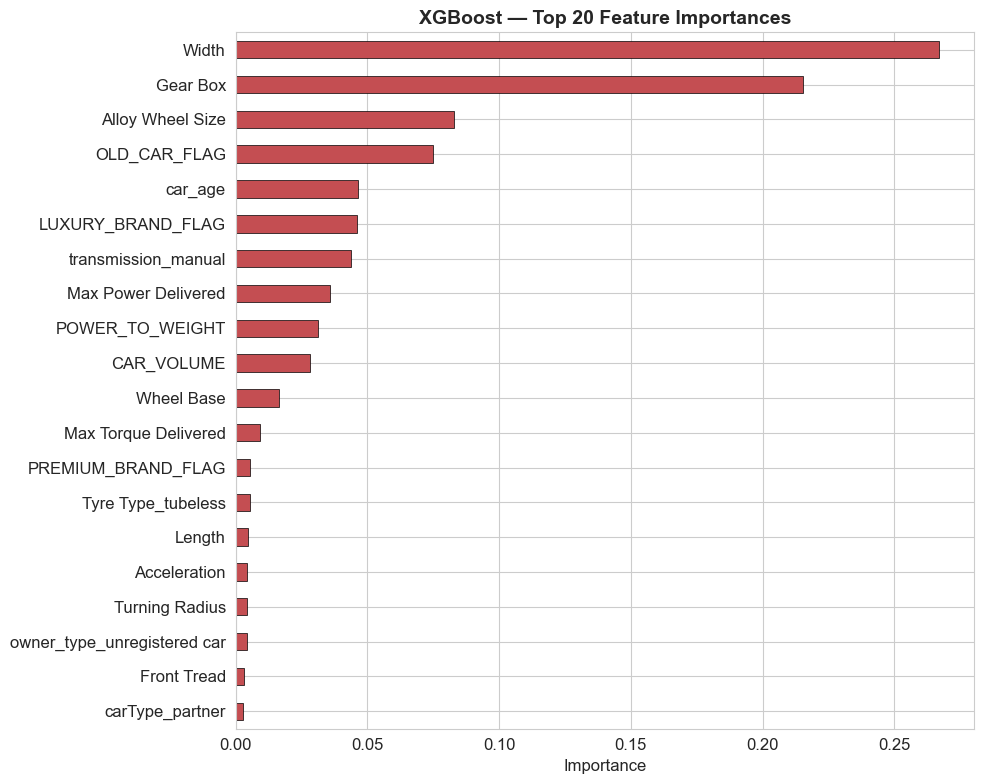

In [17]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
xgb_top20 = xgb_importance.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
xgb_top20.sort_values().plot(kind='barh', ax=ax, color='#C44E52', edgecolor='black', linewidth=0.5)
ax.set_title('XGBoost — Top 20 Feature Importances', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 15 · Prediction Error Distribution

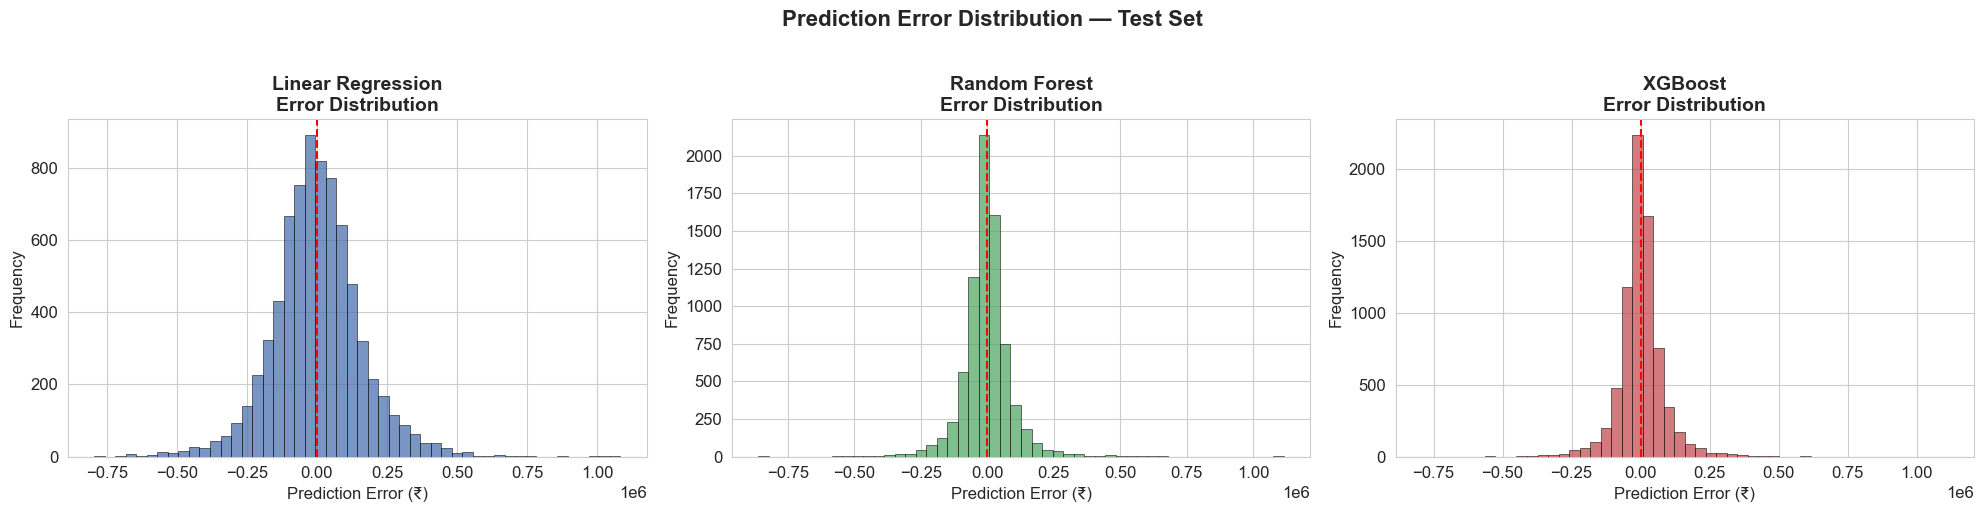

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (name, y_pred) in enumerate(predictions.items()):
    errors = y_test - y_pred
    axes[idx].hist(errors, bins=50, color=colors[idx], edgecolor='black', 
                   linewidth=0.5, alpha=0.75)
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'{name}\nError Distribution', fontweight='bold')
    axes[idx].set_xlabel('Prediction Error (₹)')
    axes[idx].set_ylabel('Frequency')

plt.suptitle('Prediction Error Distribution — Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 16 · Summary & Conclusion

In [19]:
print('=' * 70)
print('  📋  BASELINE MODELS — FINAL SUMMARY')
print('=' * 70)
print()

best_model = results_df['Test R²'].idxmax()
best_r2 = results_df.loc[best_model, 'Test R²']
best_mae = results_df.loc[best_model, 'Test MAE']
best_rmse = results_df.loc[best_model, 'Test RMSE']

for _, row in results_df.iterrows():
    model_name = row.name
    print(f'  🔹 {model_name}')
    print(f'     Test MAE  : ₹{row["Test MAE"]:>12,.0f}')
    print(f'     Test RMSE : ₹{row["Test RMSE"]:>12,.0f}')
    print(f'     Test R²   :  {row["Test R²"]:>11.4f}')
    gap = row['Train R²'] - row['Test R²']
    print(f'     Overfit Δ :  {gap:>11.4f} (Train R² - Test R²)')
    print()

print(f'  🏆  Best Baseline Model: {best_model}')
print(f'     → R² = {best_r2:.4f} | MAE = ₹{best_mae:,.0f} | RMSE = ₹{best_rmse:,.0f}')
print()
print('=' * 70)

  📋  BASELINE MODELS — FINAL SUMMARY

  🔹 Linear Regression
     Test MAE  : ₹     118,221
     Test RMSE : ₹     160,144
     Test R²   :       0.8760
     Overfit Δ :       0.0038 (Train R² - Test R²)

  🔹 Random Forest
     Test MAE  : ₹      59,576
     Test RMSE : ₹      92,294
     Test R²   :       0.9588
     Overfit Δ :       0.0304 (Train R² - Test R²)

  🔹 XGBoost
     Test MAE  : ₹      55,064
     Test RMSE : ₹      85,434
     Test R²   :       0.9647
     Overfit Δ :       0.0285 (Train R² - Test R²)

  🏆  Best Baseline Model: XGBoost
     → R² = 0.9647 | MAE = ₹55,064 | RMSE = ₹85,434



---
**Next Steps:**
- Hyperparameter tuning on the best-performing model
- Feature selection / dimensionality reduction
- Try stacking / blending ensemble approaches
- Cross-validation for more robust performance estimates
---